In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random

DATASET_DIR = Path("../urban_sound_dataset_split")
METADATA_PATH = DATASET_DIR / "clips_metadata_with_splits.csv"

df = pd.read_csv(METADATA_PATH)

print(df.head())
print()
print("Total clips:", len(df))

              clip_filename                            relative_path  \
0  bs_ozyegin16_clip025.wav     bird_sounds\bs_ozyegin16_clip025.wav   
1    pt_plane01_clip007.wav  public_transport\pt_plane01_clip007.wav   
2    pt_plane02_clip005.wav  public_transport\pt_plane02_clip005.wav   
3     ft_koru09_clip003.wav          footsteps\ft_koru09_clip003.wav   
4      pt_bus01_clip034.WAV    public_transport\pt_bus01_clip034.WAV   

              label  duration_sec            device  split  
0       bird_sounds           NaN  Zoom H4essential  train  
1  public_transport           2.0  Zoom H4essential  train  
2  public_transport           2.0  Zoom H4essential  train  
3         footsteps           NaN  Zoom H4essential  train  
4  public_transport           NaN  Zoom H4essential  train  

Total clips: 1219


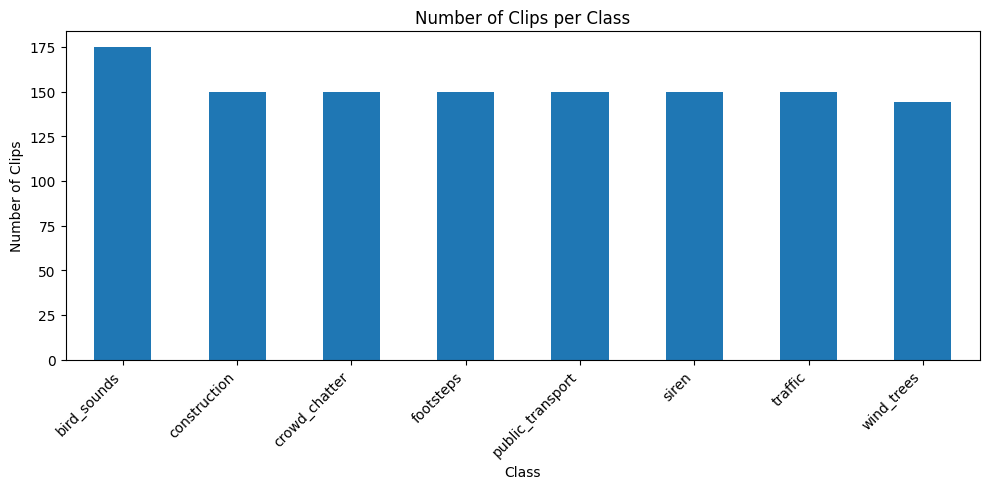

In [3]:
class_counts = df["label"].value_counts().sort_index()
class_counts
plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Number of Clips per Class")
plt.xlabel("Class")
plt.ylabel("Number of Clips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

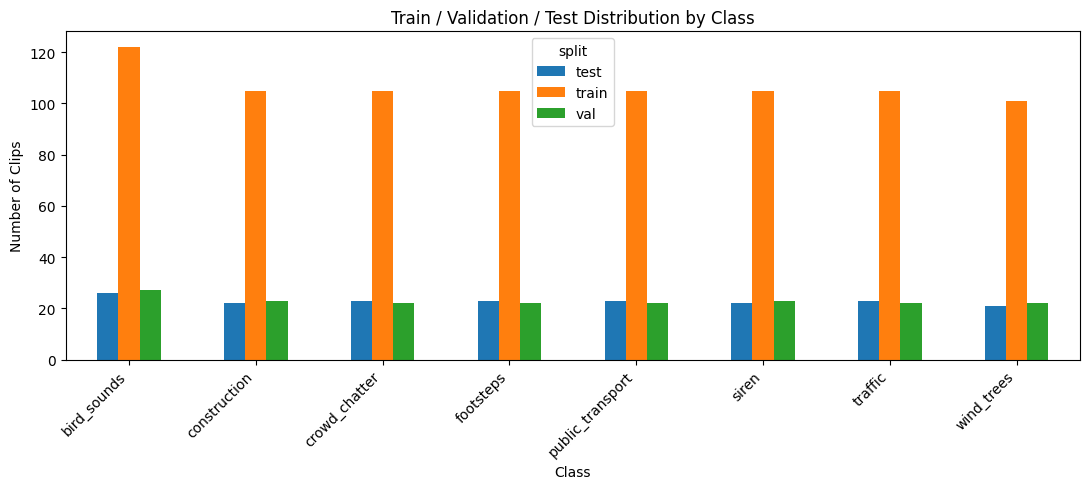

In [4]:
split_counts = df.groupby(["split", "label"]).size().unstack(fill_value=0)
split_counts
split_counts.T.plot(kind="bar", figsize=(11, 5))
plt.title("Train / Validation / Test Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Clips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

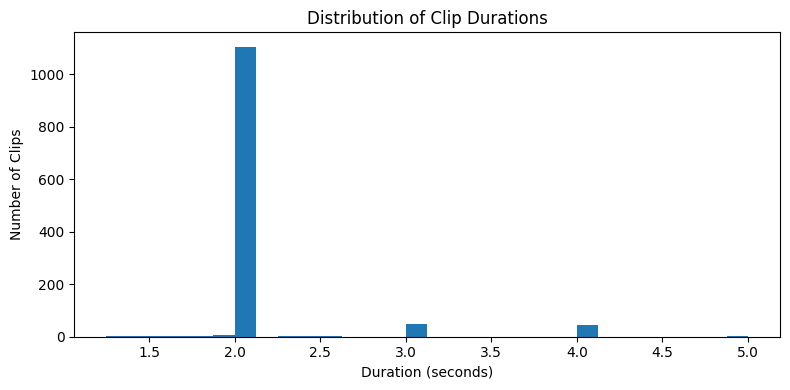

In [5]:
durations = []

for _, row in df.iterrows():
    file_path = DATASET_DIR / row["split"] / row["label"] / row["clip_filename"]
    y, sr = librosa.load(file_path, sr=None, mono=True)
    durations.append(len(y) / sr)

df["duration_sec_checked"] = durations

df["duration_sec_checked"].describe()
plt.figure(figsize=(8, 4))
plt.hist(df["duration_sec_checked"], bins=30)
plt.title("Distribution of Clip Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Clips")
plt.tight_layout()
plt.show()

In [6]:
TARGET_SR = 16000
TARGET_DURATION = 2.0
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def load_audio_fixed(path, target_sr=TARGET_SR, target_length=TARGET_LENGTH):
    y, sr = librosa.load(path, sr=target_sr, mono=True)

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode="constant")
    else:
        y = y[:target_length]

    return y, target_sr

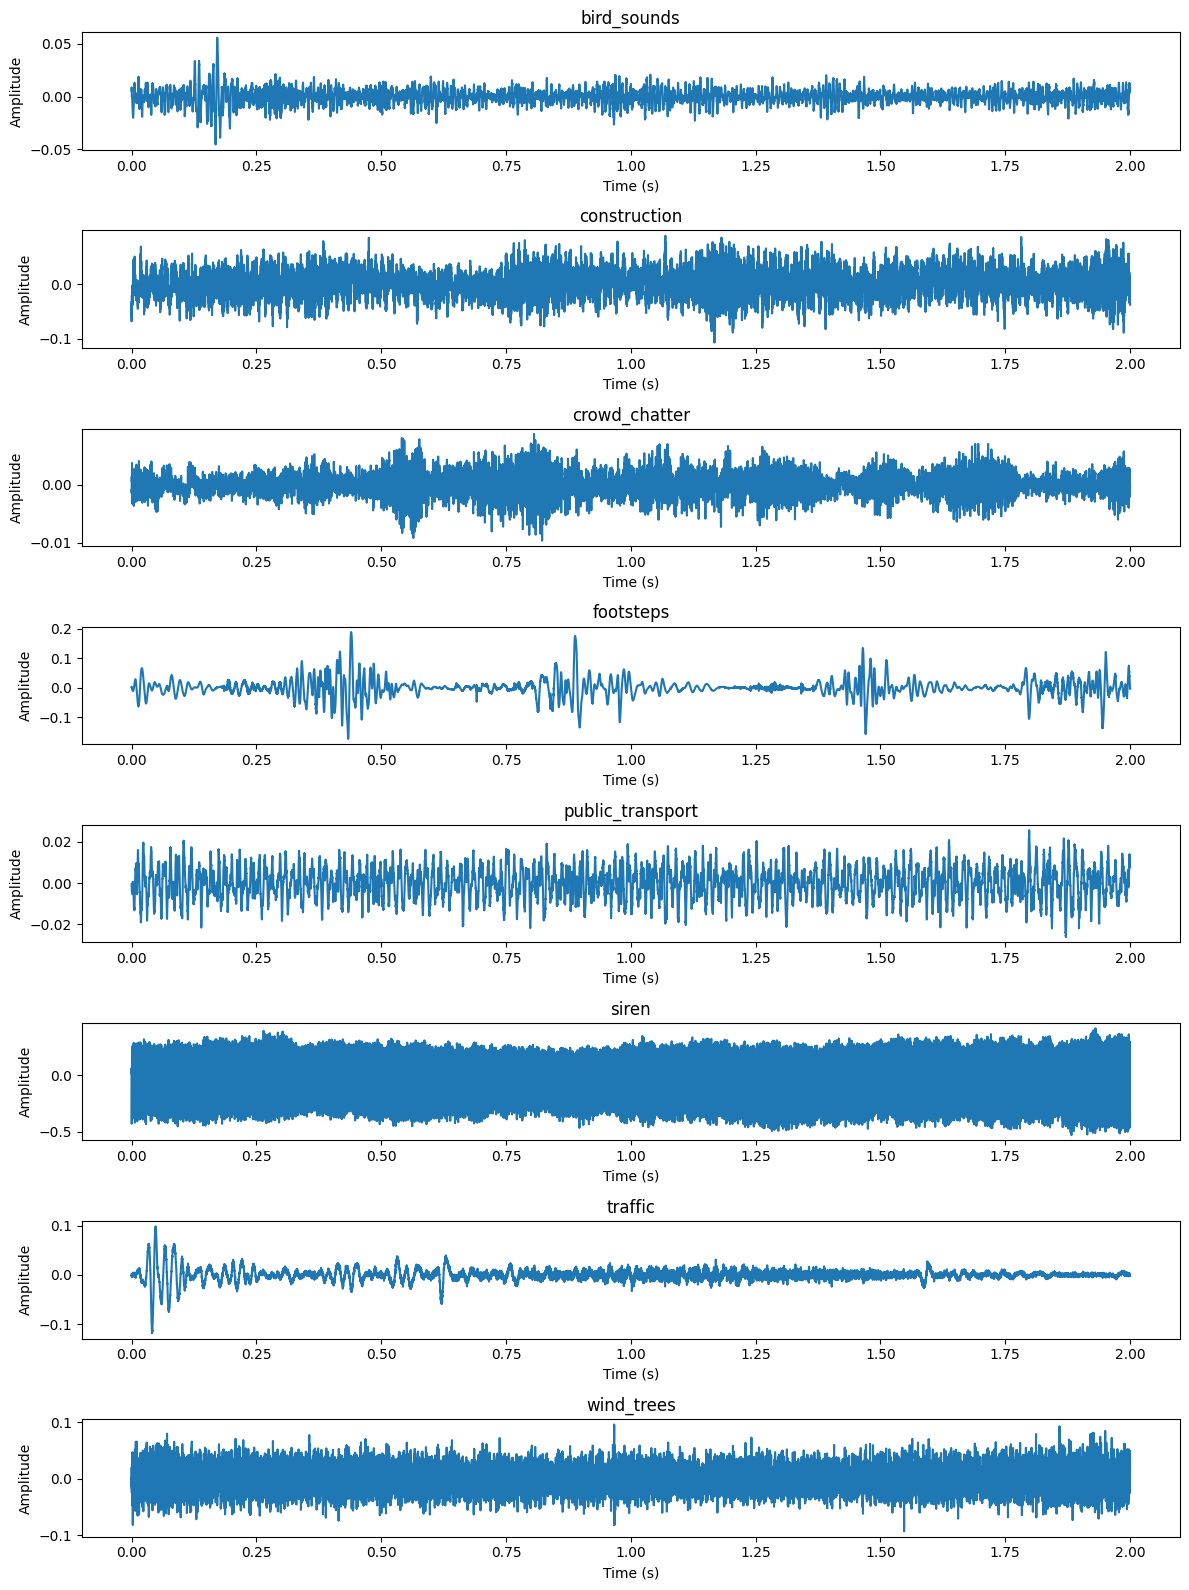

In [7]:
labels = sorted(df["label"].unique())

plt.figure(figsize=(12, 16))

for i, label in enumerate(labels):
    sample = df[df["label"] == label].sample(1, random_state=42).iloc[0]
    path = DATASET_DIR / sample["split"] / sample["label"] / sample["clip_filename"]

    y, sr = load_audio_fixed(path)
    time = np.linspace(0, len(y) / sr, len(y))

    plt.subplot(len(labels), 1, i + 1)
    plt.plot(time, y)
    plt.title(label)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

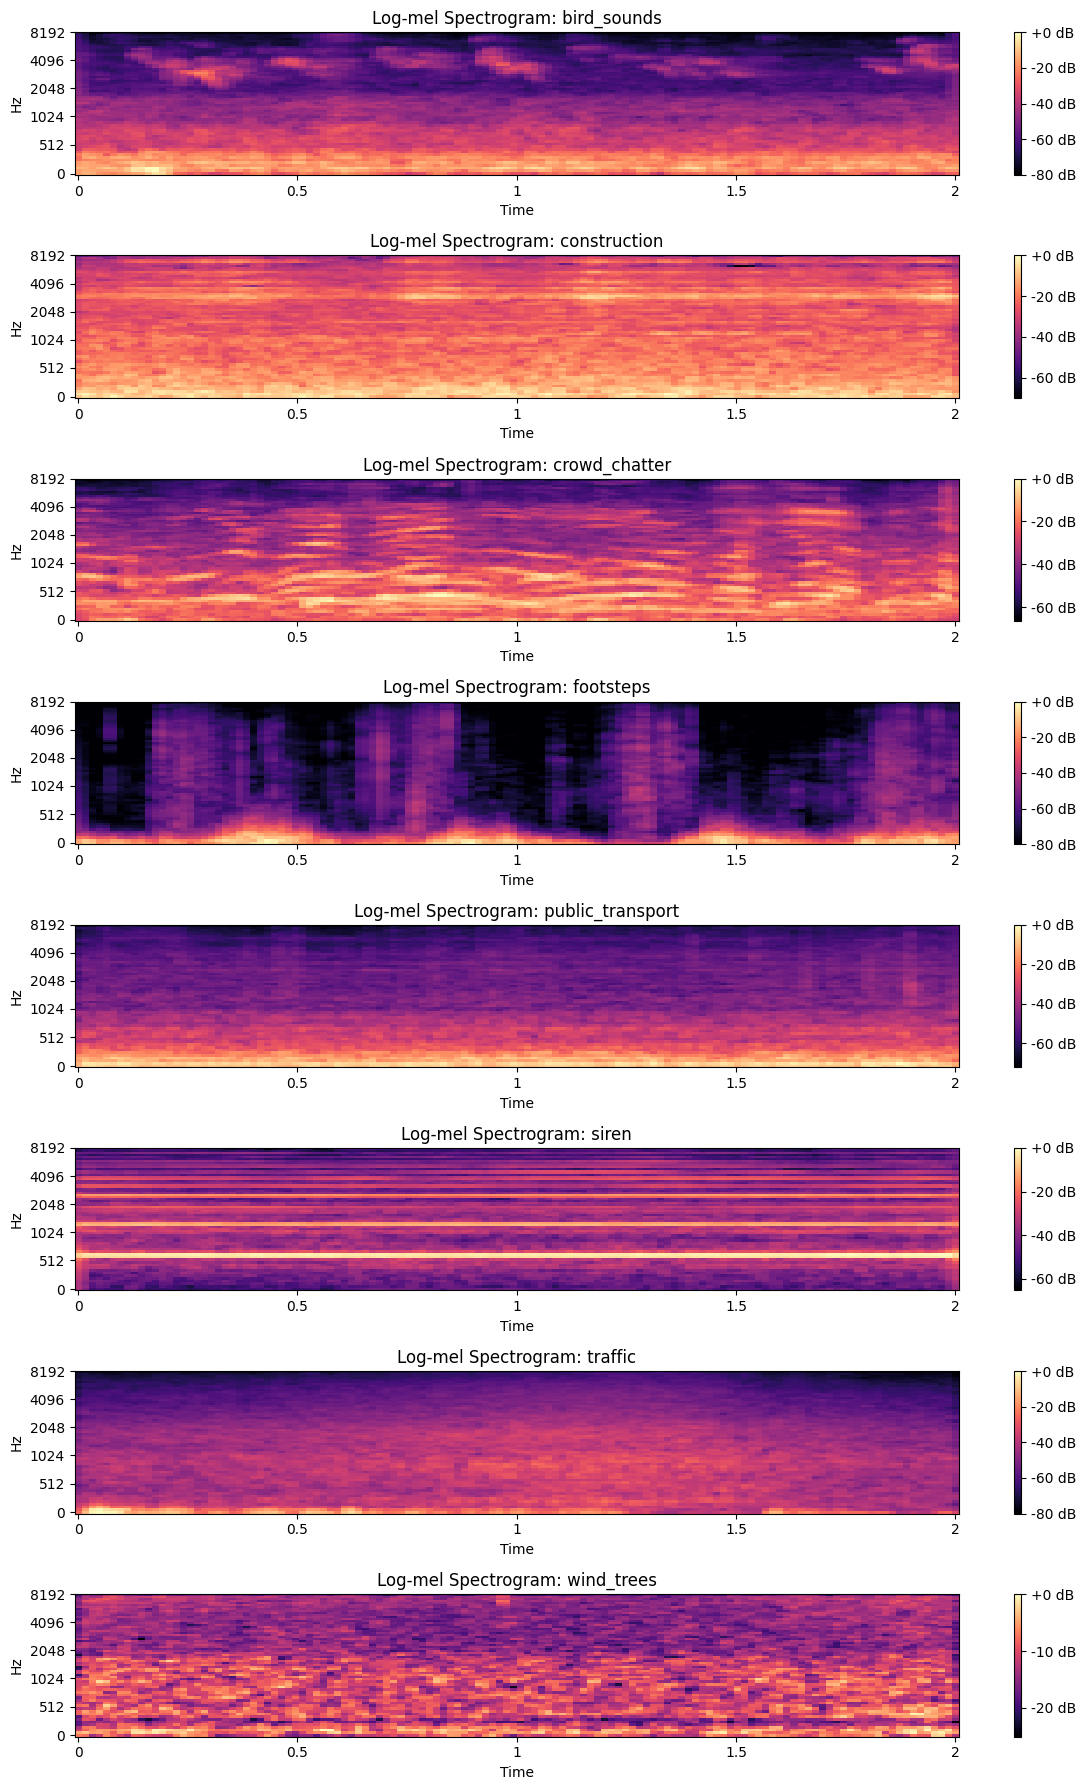

In [8]:
def audio_to_logmel(y, sr):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=256,
        n_mels=64
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel

plt.figure(figsize=(12, 18))

for i, label in enumerate(labels):
    sample = df[df["label"] == label].sample(1, random_state=42).iloc[0]
    path = DATASET_DIR / sample["split"] / sample["label"] / sample["clip_filename"]

    y, sr = load_audio_fixed(path)
    log_mel = audio_to_logmel(y, sr)

    plt.subplot(len(labels), 1, i + 1)
    librosa.display.specshow(
        log_mel,
        sr=sr,
        hop_length=256,
        x_axis="time",
        y_axis="mel"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Log-mel Spectrogram: {label}")

plt.tight_layout()
plt.show()

In [9]:
summary = {
    "total_clips": len(df),
    "num_classes": df["label"].nunique(),
    "target_sample_rate": TARGET_SR,
    "target_duration": TARGET_DURATION,
}

summary

df.to_csv(DATASET_DIR / "clips_metadata_checked.csv", index=False)
print("Saved checked metadata.")

Saved checked metadata.
